In [1]:
from rnd_spectra.bumps import Bumps
from rnd_spectra.ontheflydataset import OnTheFlyDataset, pointwise_G_normalization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
sns.set_theme(style="ticks",palette='tab10',rc={'axes.labelsize':14})
from torch.utils.data import DataLoader
from tld.configs import ModelConfig, TrainConfig, SpectralDataConfig, DenoiserConfig
from tld.diffusion import DiffusionGenerator
from tld.train import main
from dataclasses import asdict

In [2]:
hparams = {
    'omega_domain': (0, 50.0),
    'num_bumps_range': (1,4), 
    'bump_widths_fraction_range': (0.1, 0.6), 
    'bump_centers_fraction_range': (0.0, 0.5)
}
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)

In [23]:
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
dataloader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=0)

0.9995436315785142
0.9991176220576664
0.9999412706672062
0.9987613198580872
0.997540141326397
0.9990590613766844
0.9995877096622316
0.9994473857424784
0.999848415886495


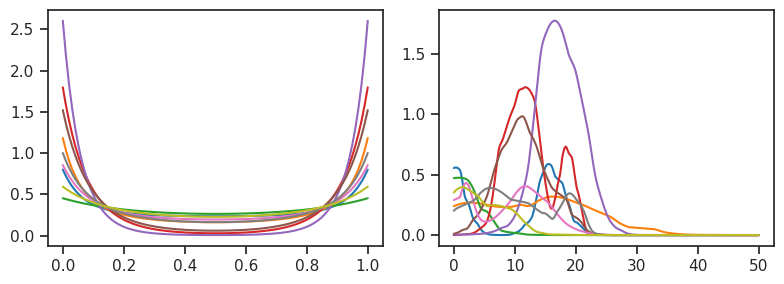

In [47]:
tau = dataloader.dataset.laplace.tau
omega = dataloader.dataset.laplace.omega
palette = ['C' + str(x) for x in range(250000)]
n_ex = 9
for C, G in dataloader:
    fig,axs = plt.subplots(1,2,figsize=(8,3))
    for j in range(n_ex):
        axs[0].plot(tau,G[j].cpu().detach().numpy().flatten(), color=palette[j])   
        # print(np.trapz(y=G[j].cpu().detach().numpy().flatten(),x=tau)*np.pi)
        axs[1].plot(omega,C[j].cpu().detach().numpy().flatten(), color=palette[j])
        print(np.trapz(y=C[j].cpu().detach().numpy().flatten()*(( 1 - np.exp(-omega) + 1e-20 ) / ( omega + 1e-20 )),x=omega))
    plt.tight_layout()
    plt.show()

# Pointwise Normalization of G
G has 4 channels

In [ ]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(omega_domain=(0,50),num_bumps_range=(1,4),bump_widths_fraction_range=(0.1, 0.6),bump_centers_fraction_range=(0.0, 0.5)),
    denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256),
    train_config=TrainConfig(compile=False, lr=3e-4, batch_size=50,n_epoch=100,use_wandb=True,save_model=True,model_name='diffusion_pointwise_norm_G')
    )
model = main(model_cfg, pointwise_norm=True)

Creating training loader:
model prep


wandb: Currently logged in as: sagimeir (sagimeir-tel-aviv-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


The model has 11383564 parameters


100%|██████████| 400/400 [01:30<00:00,  4.41it/s]


epoch: 1 | train_loss: 2.1857194492220877


...

100%|██████████| 400/400 [01:38<00:00,  4.07it/s]


epoch: 8 | train_loss: 0.509553234949708


100%|██████████| 400/400 [01:37<00:00,  4.12it/s]


epoch: 9 | train_loss: 0.5073047626763583


  5%|▍         | 19/400 [00:04<01:32,  4.10it/s]

In [4]:
from tld.denoiser import Denoiser
model = Denoiser(**asdict(model_cfg.denoiser_config))
model.load_state_dict(torch.load('diffusion_pointwise_norm_G',map_location=torch.device('cuda'))["model_ema"])

<All keys matched successfully>

In [4]:
# model_cfg = ModelConfig(
#     data_config=SpectralDataConfig(omega_domain=(0,50),num_bumps_range=(1,4),bump_widths_fraction_range=(0.1, 0.6),bump_centers_fraction_range=(0.0, 0.5)),
#     denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256),
#     train_config=TrainConfig(
#         compile=False, 
#         lr=3e-5, 
#         batch_size=50,
#         n_epoch=2000,
#         use_wandb=True,
#         save_model=True,
#         model_name='diffusion_pointwise_norm_G',
#         from_scratch=False,
#         run_id = '7d56paic'
#     )
# )
# model = main(model_cfg, pointwise_norm=True)

In [5]:
# hparams = asdict(model_cfg.data_config)
hparams = {
    'omega_domain': (0, 50.0),
    'num_bumps_range': (1,4), 
    'bump_widths_fraction_range': (0.1, 0.45), 
    'bump_centers_fraction_range': (0.0, 0.6)
}
random_seed = 20
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9, pointwise_norm=True)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test in test_loader:
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 4, 99])


In [ ]:
( torch.searchsorted(enc_G.possible_G_vals, G_test.squeeze(1).squeeze(0)) ).shape

torch.Size([9, 99])

In [26]:
enc_G.CDF[( torch.searchsorted(enc_G.possible_G_vals, G_test.squeeze(1).squeeze(0)) ),:].diagonal(dim1=1,dim2=2).shape

torch.Size([9, 99])

In [ ]:
# enc_G = pointwise_G_normalization(mean=torch.Tensor([ 3.3555e-01, -2.2111e+00, -1.2480e-03,  5.0047e-01]), std=torch.Tensor([0.4986, 2.0547, 1.1408, 0.2882]))
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list = [diffuser.generate(
        labels= (G_test).to('cuda'),
        num_specs=9,
        class_guidance=1.,
        seed=i,
        # n_iter=40,
        x_points=1024,
        use_ddpm_plus=False,
        # constraint_guidance=0.1,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
        # prior_knowledge=C_test.to('cuda'),
        # directed_positivity=True
    ).view(-1,1024).cpu().detach().numpy() for i in range(3)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

  0%|          | 0/999 [00:00<?, ?it/s]

100%|██████████| 999/999 [00:48<00:00, 20.80it/s]


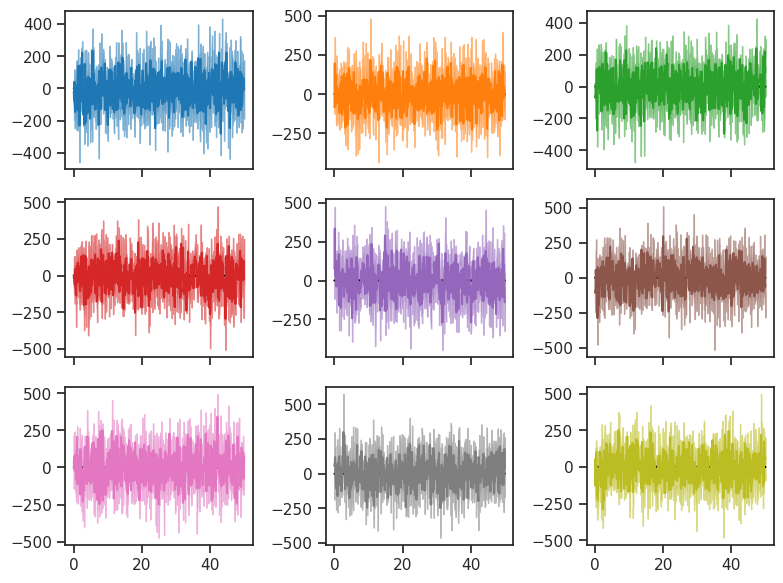

In [10]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    # for i in range(20):
    #     ax.plot(omega,C_preds_array[i][j], color=palette[j],alpha=0.3,linewidth=0.5)
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

In [37]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list = [diffuser.generate(
        labels= (torch.zeros_like(G_test)).to('cuda'),
        num_specs=9,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        # constraint_guidance=0.1,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
        # prior_knowledge=C_test.to('cuda'),
        # directed_positivity=True
    ).view(-1,1024).cpu().detach().numpy() for i in range(1)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

  0%|          | 0/39 [00:00<?, ?it/s]

100%|██████████| 39/39 [00:01<00:00, 23.90it/s]


In [13]:
C_preds_array[1].shape

(9, 1024)

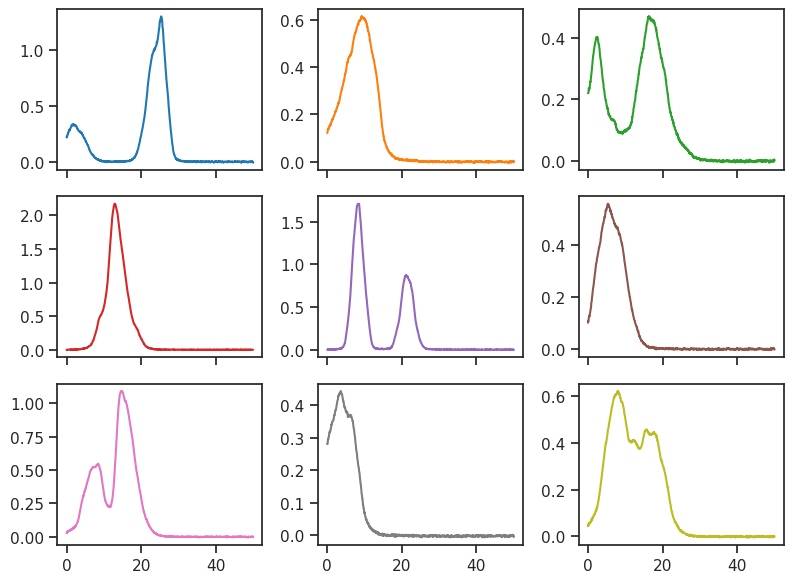

In [38]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    # ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    # ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.3)
    # for i in range(20):
    #     ax.plot(omega,C_preds_array[i][j],'--', color='k',alpha=0.3,linewidth=0.5)
plt.tight_layout()
plt.show()

In [7]:
#params
kB = 3.1668114E-6  # in Hartree/K
c = 2.99792458E10  # speed of light in cm/s
s_in_t_au = 2.4188843265857E-17  # 1 time a.u. in s

T = 14.0  # in K

b = 1 / (kB * T)
print('beta is ' + str(b))


# rabani input:
Nbeads = 219
Natoms = 180
tau = test_loader.dataset.laplace.tau
# omega_dummy = np.linspace(omega_range[0], omega_range[1], Ng_w)

G_rabani = np.load('data/barak/G_Rabani_' + str(T) + 'K_' + str(Natoms) + 'p.npy')
tau_PIMD = G_rabani[0]
G_rabani = G_rabani[1]

# adds points to G
G_rabani_interp = np.interp(tau, tau_PIMD, G_rabani)
Norm_rabani = np.trapz(G_rabani_interp,tau)*np.pi
G_rabani_interp = G_rabani_interp / Norm_rabani

G_anal_tensor = torch.Tensor(G_rabani_interp)

# rabani output:
import pandas as pd
rabani_data = pd.read_csv("data/Rabani_D_w_14K.csv", sep=",", header=None)
rabani_data_w, rabani_data_D = rabani_data[0].values,rabani_data[1].values
rabani_data_w *= ( 2 * np.pi * c * s_in_t_au * b ) # now omega unitless

rabani_D_interp = np.interp(omega, rabani_data_w, rabani_data_D)
rabani_D_interp/= np.trapz(y=rabani_D_interp * (1-np.exp(-omega) + 1e-30)/(omega + 1e-30),x=omega)

# # PIMD with I-pi input:
Nbeads = 50
df=pd.read_csv('/home/sagi/Desktop/parahydrogen/pH2_for_Amit/G_14K_50beads_180p_ipi_sym.csv')
_, G_rabani = df['tau'].values,df['G'].values

# # interpolate - adding points to G
tau_PIMD = np.linspace(0,1,Nbeads+1)
G_rabani_interp_2 = np.interp(tau, tau_PIMD, G_rabani)
Correct_norm = np.trapz(G_rabani_interp_2,tau)*np.pi
G_rabani_interp_2 = G_rabani_interp_2 / Correct_norm 

G_anal_tensor_2 = torch.Tensor(G_rabani_interp_2)

beta is 22555.360078775586


In [8]:
enc_G = pointwise_G_normalization(mean=torch.Tensor([ 0.3319, -1.8394,  0.0023,  0.5002]), std=torch.Tensor([0.4170, 1.5327, 1.1582, 0.2884]))
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list_rabani = [diffuser.generate(
        labels= enc_G(G_anal_tensor.view(1,-1)).unsqueeze(0).to('cuda'),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        # constraint_guidance=0.01,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_rabani)
C_preds_mean_rabani = C_preds_array.mean(0)
C_preds_std_rabani = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 160.12it/s]


In [9]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list_rabani = [diffuser.generate(
        labels= enc_G(G_anal_tensor_2.view(1,-1)).unsqueeze(0).to('cuda'),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        # constraint_guidance=0.01,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_rabani)
C_preds_mean_rabani_2 = C_preds_array.mean(0)
C_preds_std_rabani_2 = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 156.06it/s]


In [10]:
mass=2.01588 # gram/mol
hbar = 1.054571817 * 1E-34 # J * sec = kg * m^2 /sec
hbar *= 1E+20 # kg * angstrom^2 /sec
hbar *= 1E-12 # kg * angstrom^2 /ps
mass /= (1000 * 6.02214076 * 1E+23) # kg
renorm_factor = hbar*3*np.pi/mass

0.5182432274056049
0.5654142545432609
0.2881096360834827


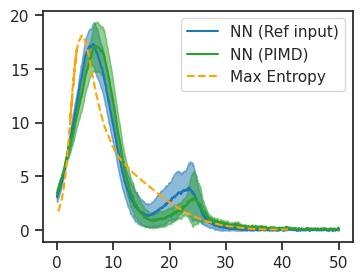

In [11]:
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(omega,renorm_factor*C_preds_mean_rabani[0],label='NN (Ref input)',color='tab:blue')
ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani[0]-C_preds_std_rabani[0]),renorm_factor*(C_preds_mean_rabani[0]+C_preds_std_rabani[0]),color='tab:blue',alpha=0.5)
print(renorm_factor*C_preds_mean_rabani[0][0]/6)
ax.plot(omega,renorm_factor*C_preds_mean_rabani_2[0],color='tab:green',label='NN (PIMD)')
ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani_2[0]-C_preds_std_rabani_2[0]),renorm_factor*(C_preds_mean_rabani_2[0]+C_preds_std_rabani_2[0]),color='tab:green',alpha=0.5)
print(renorm_factor*C_preds_mean_rabani_2[0][0]/6)
ax.plot(rabani_data_w,rabani_data_D*6,'--',color='orange',label='Max Entropy')
print(rabani_data_D[0])
ax.legend()

water

In [15]:
velFT = np.loadtxt('/home/sagi/Desktop/water/1bead/nve1/nve_facf.data', usecols=(0,1))
velFT = velFT[velFT[:,0] * 219474<=8000]
water_data_w, water_nve_D = velFT[:,0]* 219474 * ( 2 * np.pi * c * s_in_t_au /kB/300 ), velFT[:,1]
norm_water_nve_D=np.trapz(y=water_nve_D,x=water_data_w)
water_nve_D/=norm_water_nve_D
water_nve_D *= (water_data_w + 1E-30) / (1-np.exp(-water_data_w) + 1E-30)


Nbeads = 32
df=pd.read_csv('/home/sagi/Desktop/water/G_300K_32beads_sym.csv')
_, G_water = df['tau'].values,df['G'].values

G_water_interp = np.interp(tau, np.linspace(0,1,Nbeads+1), G_water)
Norm_water = np.trapz(G_water_interp,tau)*np.pi
G_water_interp = G_water_interp / Norm_water
G_water_tensor = torch.Tensor(G_water_interp)

K = ( np.exp(- water_data_w * tau[:,None]) + np.exp(water_data_w * (tau - 1)[:,None]) )/2/np.pi
G_water_interp2 = np.trapz(y=K*water_nve_D,x=water_data_w)
print(np.trapz(y=G_water_interp2,x=tau)*np.pi)
G_water_tensor2 = torch.Tensor(G_water_interp2)

water_nve_D_interp = np.interp(omega, water_data_w, water_nve_D)

1.000926779558307


In [16]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list_water = [(diffuser.generate(
        labels= enc_G(G_water_tensor.view(1,-1)).unsqueeze(0).to('cuda'),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        # constraint_guidance=0.8,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
        # prior_knowledge=torch.Tensor(water_nve_D_interp).to('cuda'),
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_water)
C_preds_mean_water = C_preds_array.mean(0)
C_preds_std_water = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 159.75it/s]


In [17]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list_water = [(diffuser.generate(
        labels= enc_G(G_water_tensor2.view(1,-1)).unsqueeze(0).to('cuda'),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True,
        # constraint_guidance=0.8,
        # tau = test_loader.dataset.laplace.tau,
        # omega = test_loader.dataset.laplace.omega,
        # prior_knowledge=torch.Tensor(water_nve_D_interp).to('cuda'),
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_water)
C_preds_mean_water2 = C_preds_array.mean(0)
C_preds_std_water2 = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 158.10it/s]


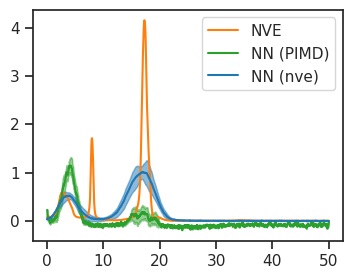

In [18]:
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(omega,water_nve_D_interp,color='tab:orange',label='NVE')
ax.plot(omega,C_preds_mean_water[0],label='NN (PIMD)',color='tab:green')
ax.fill_between(omega,(C_preds_mean_water[0]-C_preds_std_water[0]),(C_preds_mean_water[0]+C_preds_std_water[0]),color='tab:green',alpha=0.5)
ax.plot(omega,C_preds_mean_water2[0],label='NN (nve)',color='tab:blue')
ax.fill_between(omega,(C_preds_mean_water2[0]-C_preds_std_water2[0]),(C_preds_mean_water2[0]+C_preds_std_water2[0]),color='tab:blue',alpha=0.5)

ax.legend()

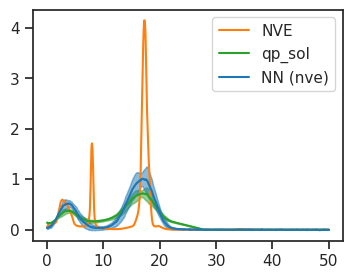

In [490]:
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(omega,water_nve_D_interp,color='tab:orange',label='NVE')
ax.plot(omega,C_qp_mean,label='qp_sol',color='tab:green')
ax.fill_between(omega,(C_qp_mean-C_qp_std),(C_qp_mean+C_qp_std),color='tab:green',alpha=0.5)
ax.plot(omega,C_preds_mean_water2[0],label='NN (nve)',color='tab:blue')
ax.fill_between(omega,(C_preds_mean_water2[0]-C_preds_std_water2[0]),(C_preds_mean_water2[0]+C_preds_std_water2[0]),color='tab:blue',alpha=0.5)

ax.legend()